In [136]:
import numpy as np
import preliz as pz

# Exercise 1: Maternity Ward Planning

a) The Poisson distribution is an appropriate model if: $E[Y] = Var[Y] = \lambda$

In [137]:
y = np.array([6,11,12,9,11,10,9,18,9,18,12,14,9,11,10,15,13,11,14,12,11,8,11,13,11,12,20,5,13,16])
print(f"E[Y] = {y.mean()}, Var[Y] = {y.var()}, mean(E[Y], Var[Y]) = {(y.mean() + y.var()) / 2:.3f}")

E[Y] = 11.8, Var[Y] = 10.76, mean(E[Y], Var[Y]) = 11.280


Both are roughly the same, so we use $\lambda = 11.28$

For $\lambda \sim Gamma(s, r)$:

- $E[\lambda] = \dfrac{s}{r}$
- $Var[\lambda] = \dfrac{s}{r^2}$

And because we know $E[\lambda] = 15$ we can solve for $s$:

$$
\begin{align}
E[\lambda] &= \dfrac{s}{r}\\
15 &= \dfrac{s}{r}\\
s &= 15 \cdot r\\
\end{align}
$$

<Axes: >

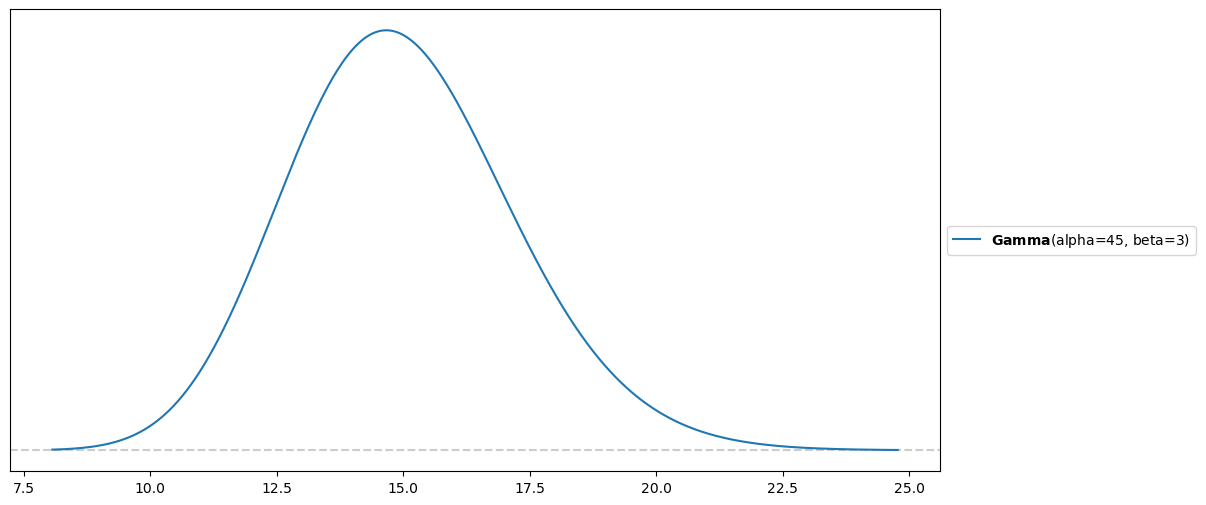

In [138]:
import preliz as pz

r = 3
s = 15 * r

pz.Gamma(s, r).plot_pdf(figsize=(12, 6))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambd]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambd,14.978,2.23,10.951,19.395,0.055,0.033,1609.0,2515.0,1.0


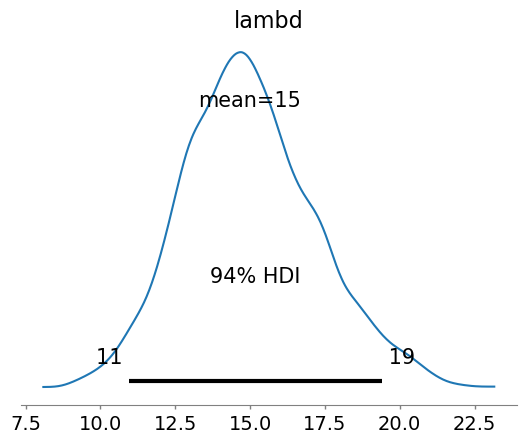

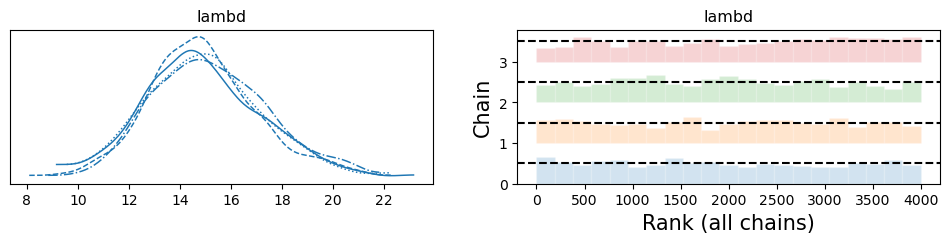

In [139]:
import pymc as pm
import arviz as az

# Disable C compilation by using the Python-only mode:
import pytensor
pytensor.config.cxx = ""

with pm.Model() as model:
    lambd = pm.Gamma('lambd', alpha = s, beta = r)
    samples = pm.sample(1000)

az.plot_posterior(samples)
az.plot_trace(samples, kind = "rank_bars")
az.summary(samples)

d) Full model:

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambd]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 4 seconds.


array([[<Axes: title={'center': 'lambd'}>,
        <Axes: title={'center': 'lambd'}, xlabel='Rank (all chains)', ylabel='Chain'>]],
      dtype=object)

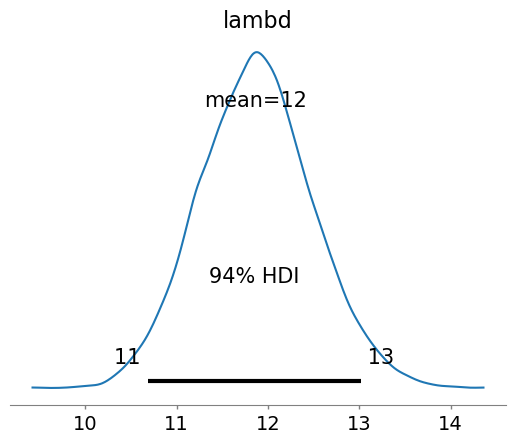

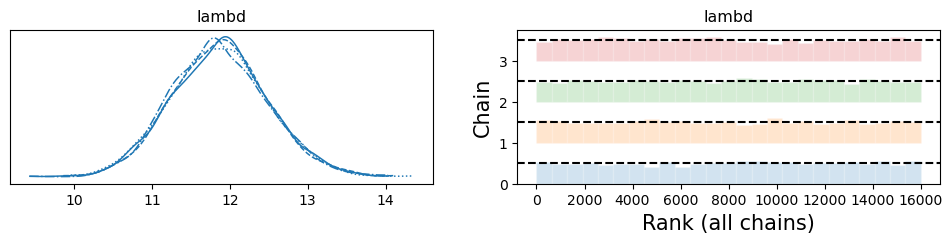

In [140]:
import pymc as pm
import arviz as az

# Disable C compilation by using the Python-only mode:
import pytensor
pytensor.config.cxx = ""

with pm.Model() as model:
    lambd = pm.Gamma('lambd', mu = 15, sigma = 5)
    y = pm.Poisson('y', mu = lambd, observed = [6,11,12,9,11,10,9,18,9,18,12,14,9,11,10,15,13,11,14,12,11,8,11,13,11,12,20,5,13,16])
    samples = pm.sample(4000)

az.plot_posterior(samples)
az.plot_trace(samples, kind = "rank_bars")

The chain ranks look good

array([[<Axes: title={'center': 'lambd'}>]], dtype=object)

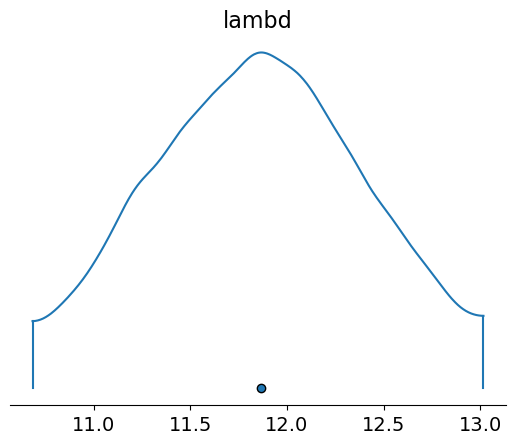

In [141]:
az.plot_density(samples)

The density plot looks good

<Axes: title={'center': 'lambd'}>

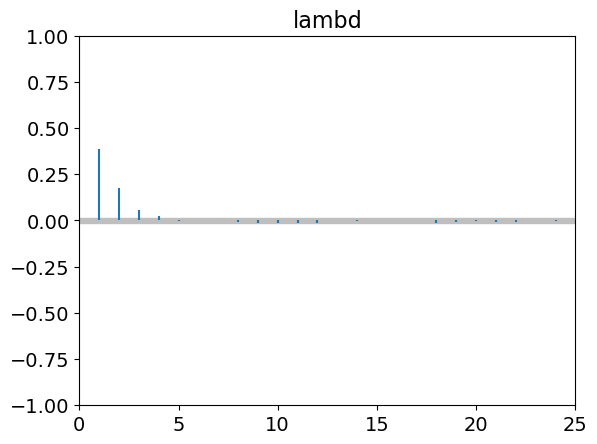

In [142]:
az.plot_autocorr(samples, max_lag = 25, combined = True)

The autocorrelation drops off very quickly, that's a good sign.

In [143]:
n = 16_000
ess = az.ess(samples).lambd.values
print(f"ess = {ess:.4f}, ess / n = {ess / n:.4f}")

ess = 6988.0573, ess / n = 0.4368


In [144]:
az.summary(samples)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambd,11.868,0.62,10.682,13.018,0.007,0.004,6988.0,11471.0,1.0


- ✅ Good: $\hat{R} < 1.05$ (We aim for it to be close to 1, because it means that the total variance is the same as the within variance)
- ✅ Good: $ESS / N > 10\%$: We do have approximately 41%

d)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambd,11.868,0.62,10.69,13.128,0.007,0.004,6988.0,11471.0,1.0


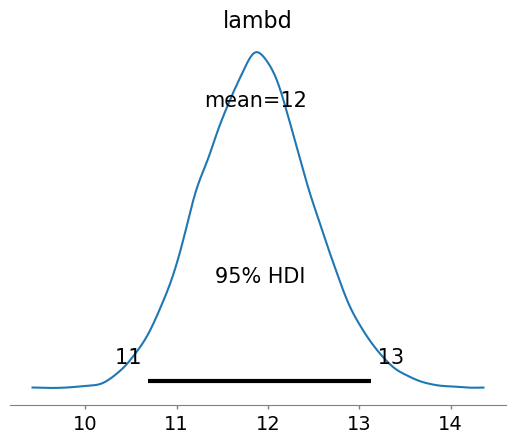

In [150]:
az.plot_posterior(samples, var_names = ['lambd'], hdi_prob = 0.95)
az.summary(samples, var_names = ['lambd'], hdi_prob = 0.95)

The posterior mean is 12 and the standard deviation is +/- 0.625 beds:

"I'm 95% confident that you'll need 11-13 beds most of the time. The average is somewhere in between - most likely 12. The standard deviation is very small; its only approximately half of a bed."

e)

In [146]:
with model:
    y_hat = pm.Poisson('y_hat', mu = lambd)
    predictions = pm.sample_posterior_predictive(samples, var_names = ['y_hat'])

Sampling: [y_hat]


Output()

In [157]:
365 * np.mean( predictions.posterior_predictive.y_hat > 20 ).values

np.float64(3.74125)

g)

Aleatoric:

In [133]:
n = len([6,11,12,9,11,10,9,18,9,18,12,14,9,11,10,15,13,11,14,12,11,8,11,13,11,12,20,5,13,16])
aleatoric_vars = n * samples.posterior.lambd.values * (1 - samples.posterior.lambd.values)
aleatoric_var = np.mean(aleatoric_vars)
aleatoric_var

np.float64(-3885.42921686391)

Epistemic:

In [134]:
epistemic_var = np.var(samples.posterior.lambd.values * n)
epistemic_var

np.float64(352.30962934091946)

Predictive: